#### Test de algunos modelos

In [2]:
import pandas as pd
from ydata_profiling import ProfileReport

In [3]:
df = pd.read_csv("dataset_no_outliers.csv")

# Crear el reporte
#profile = ProfileReport(df, title="Reporte del Dataset Unificado", explorative=True)

# Guardarlo como archivo HTML
#profile.to_file("dataset.html")

In [4]:
# X: todas las columnas menos la última
X = df.iloc[:, :-1]

# y: última columna
y = df.iloc[:, -1]


In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Modelos de Regresión

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


#  Extraer solo la columna freight_value de los conjuntos ya divididos
X_train_simple = X_train[['freight_value']]
X_test_simple = X_test[['freight_value']]

#  Crear y entrenar modelo
lr_simple = LinearRegression()
lr_simple.fit(X_train_simple, y_train)

#  Predecir
y_pred_simple = lr_simple.predict(X_test_simple)

#  Evaluar
print("Regresión lineal (solo freight_value)")
print("R²:", r2_score(y_test, y_pred_simple))
print("MAE:", mean_absolute_error(y_test, y_pred_simple))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_simple)))


Regresión lineal (solo freight_value)
R²: 0.22515260843989737
MAE: 0.19106081667792424
RMSE: 0.37583994297430473


In [ ]:

# Crear y entrenar el modelo
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predecir y evaluar
y_pred = lr.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.3460387501182226
MAE: 0.1926324568659545
RMSE: 0.34527954718864556


In [95]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Crear pipeline con grado polinomial 
degree = 3
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(X_train_simple, y_train)

# 4. Predecir
y_pred = poly_model.predict(X_test_simple)

# 5. Evaluar
print(f"Regresión Polinomial (grado {degree})")
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Regresión Polinomial (grado 3)
R²: 0.23517344682146235
MAE: 0.17195292662556466
RMSE: 0.37340172894870904


In [91]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Entrenar el modelo
tree = DecisionTreeRegressor(random_state=42, max_depth=15)  
tree.fit(X_train, y_train)

# 2. Predecir
y_pred_tree = tree.predict(X_test)

# 3. Evaluar
print("R²:", r2_score(y_test, y_pred_tree))
print("MAE:", mean_absolute_error(y_test, y_pred_tree))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))

R²: 0.37590647345874484
MAE: 0.0666190774232544
RMSE: 0.3373025968485127


In [92]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Crear y entrenar el modelo
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 2. Predecir
y_pred_rf = rf.predict(X_test)

# 3. Evaluar
print("Random Forest Regressor")
print("R²:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


Random Forest Regressor
R²: 0.7594372292204847
MAE: 0.06151861155514957
RMSE: 0.2094156115924151


In [93]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf')

svr_model.fit(X_train, y_train)

svr_pred = svr_model.predict(X_test)

# 5. Evaluar
print("SVR (solo freight_value)")
print("R²:", r2_score(y_test, svr_pred))
print("MAE:", mean_absolute_error(y_test, svr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, svr_pred)))


SVR (solo freight_value)
R²: 0.20327758158238118
MAE: 0.15395552229049245
RMSE: 0.3811082626888029


### Modelos de Clasificación

In [41]:
y.value_counts(normalize=True)


num_items
1.0     0.905535
2.0     0.075796
3.0     0.012480
4.0     0.004042
5.0     0.001176
6.0     0.000856
7.0     0.000091
15.0    0.000011
8.0     0.000011
Name: proportion, dtype: float64

C:\Users\Ale\AppData\Local\Temp\ipykernel_25904\1507481775.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num_items', data=df, palette="Blues")


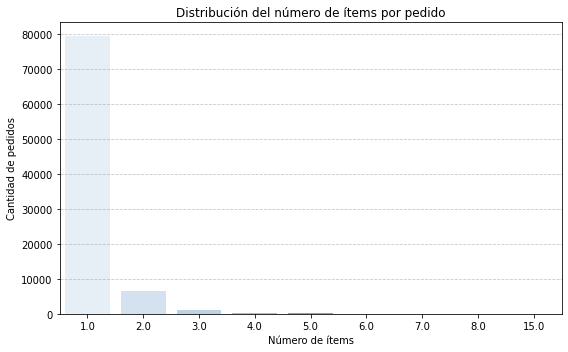

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='num_items', data=df, palette="Blues")

plt.title("Distribución del número de ítems por pedido")
plt.xlabel("Número de ítems")
plt.ylabel("Cantidad de pedidos")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [69]:
# Crear una nueva columna con clases agrupadas
def clasificar_items(n):
    if n == 1:
        return '1'
    elif n == 2:
        return '2'
    else:
        return '3+'

df['num_items_class'] = df['num_items'].apply(clasificar_items)


In [70]:
df['num_items_class'].value_counts(normalize=True)


num_items_class
1     0.905535
2     0.075796
3+    0.018669
Name: proportion, dtype: float64

In [71]:
X_classification = df.drop(columns=['num_items', 'num_items_class'])  
y_classification = df['num_items_class']


In [ ]:
# Ver cuántos ejemplos hay por clase
print(y_classification.value_counts())

# Filtrar para obtener solo aquellas clases que tengan al menos 2 instancias
valid_classes = y_classification.value_counts()[y_classification.value_counts() > 1].index
mask = y_classification.isin(valid_classes)

X_classification_filtered = X_classification[mask]
y_classification_filtered = y_classification[mask]

from sklearn.model_selection import train_test_split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_classification_filtered, y_classification_filtered, test_size=0.2, stratify=y_classification_filtered, random_state=42
)

num_items_class
1     79304
2      6638
3+     1635
Name: count, dtype: int64


C:\Users\Ale\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression ===
              precision    recall  f1-score   support

           1       0.99      0.90      0.94     15861
           2       0.39      0.69      0.50      1328
          3+       0.39      0.84      0.53       327

    accuracy                           0.88     17516
   macro avg       0.59      0.81      0.66     17516
weighted avg       0.93      0.88      0.90     17516

F1-Score (macro): 0.6553531233507801


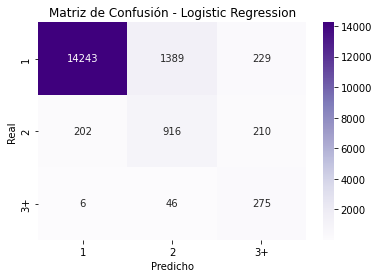

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Aplicar solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_cls, y_train_cls)

model_lr = LogisticRegression(max_iter=1000)  
model_lr.fit(X_train_res, y_train_res)

# Evaluación
y_pred_lr = model_lr.predict(X_test_cls)

print("=== Logistic Regression ===")
print(classification_report(y_test_cls, y_pred_lr))

# Macro average: todas las clases igual de importantes
f1_macro = f1_score(y_test_cls, y_pred_lr, average='macro')

print("F1-Score (macro):", f1_macro)

# Matriz de confusión
sns.heatmap(confusion_matrix(y_test_cls, y_pred_lr), annot=True, fmt='d', cmap='Purples',
            xticklabels=model_lr.classes_, yticklabels=model_lr.classes_)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Logistic Regression")
plt.show()

Decision Tree
              precision    recall  f1-score   support

           1       0.98      0.95      0.96     15861
           2       0.57      0.73      0.64      1328
          3+       0.44      0.67      0.53       327

    accuracy                           0.93     17516
   macro avg       0.66      0.78      0.71     17516
weighted avg       0.94      0.93      0.93     17516

F1-Score (macro): 0.7098648525201079


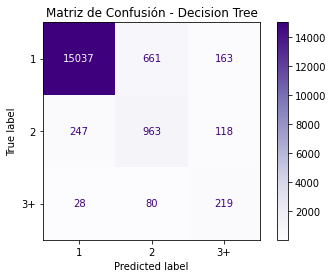

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Aplicar solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_cls, y_train_cls)

# Entrenar el modelo
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_res, y_train_res)

# Predecir
y_pred_dt = model_dt.predict(X_test_cls)

# Reporte de clasificación
print("Decision Tree")
print(classification_report(y_test_cls, y_pred_dt))

# F1-Score general
f1_macro = f1_score(y_test_cls, y_pred_dt, average='macro')

print("F1-Score (macro):", f1_macro)

# Matriz de confusión
cm = confusion_matrix(y_test_cls, y_pred_dt, labels=model_dt.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_dt.classes_)
disp.plot(cmap='Purples')
plt.title("Matriz de Confusión - Decision Tree")
plt.show()


In [ ]:
y_train_res.value_counts()


num_items_class
1     63443
2     63443
3+    63443
Name: count, dtype: int64

 Random Forest
              precision    recall  f1-score   support

           1       0.99      0.97      0.98     15861
           2       0.71      0.79      0.75      1328
          3+       0.65      0.69      0.67       327

    accuracy                           0.95     17516
   macro avg       0.78      0.82      0.80     17516
weighted avg       0.96      0.95      0.96     17516

 F1-Score macro: 0.8


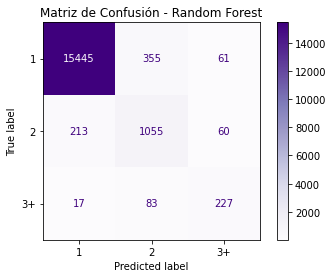

In [85]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Aplicar solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_cls, y_train_cls)

# Entrenar modelo
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_res, y_train_res)

# Predicciones
y_pred_rf = model_rf.predict(X_test_cls)

# Reporte de clasificación
print(" Random Forest")
print(classification_report(y_test_cls, y_pred_rf))

# F1-Score promedio (macro)
f1_macro = f1_score(y_test_cls, y_pred_rf, average='macro')
print(" F1-Score macro:", round(f1_macro, 3))

# Matriz de confusión
cm = confusion_matrix(y_test_cls, y_pred_rf, labels=model_rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_rf.classes_)
disp.plot(cmap="Purples")
plt.title("Matriz de Confusión - Random Forest")
plt.show()



SVC
              precision    recall  f1-score   support

           1       0.99      0.90      0.94     15861
           2       0.44      0.75      0.55      1328
          3+       0.37      0.81      0.51       327

    accuracy                           0.89     17516
   macro avg       0.60      0.82      0.67     17516
weighted avg       0.93      0.89      0.91     17516

F1-Score promedio: 0.6682354600609076


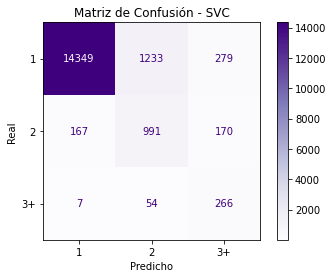

In [86]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

# Aplicar solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_cls, y_train_cls)

# Entrenar el modelo
model_svc = SVC(random_state=42)
model_svc.fit(X_train_res, y_train_res)

# Predecir
y_pred_svc = model_svc.predict(X_test_cls)

# Imprimir reporte
print("SVC")
print(classification_report(y_test_cls, y_pred_svc))

# F1-score macro promedio
f1_macro = f1_score(y_test_cls, y_pred_svc, average='macro')
print("F1-Score promedio:", f1_macro)

# Matriz de confusión
cm = confusion_matrix(y_test_cls, y_pred_svc, labels=model_svc.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_svc.classes_)
disp.plot(cmap="Purples")
plt.title("Matriz de Confusión - SVC")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()



In [79]:
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier

# Aplicar solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_cls, y_train_cls)

model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(X_train_bal, y_train_bal)

y_pred_knn = model_knn.predict(X_test_cls)
print("KNN con SMOTE")
print(classification_report(y_test_cls, y_pred_knn))

f1_macro = f1_score(y_test_cls, y_pred_knn, average='macro')
print("F1-Score promedio:", f1_macro)


KNN con SMOTE
              precision    recall  f1-score   support

           1       0.95      0.84      0.89     15861
           2       0.18      0.41      0.25      1328
          3+       0.24      0.37      0.29       327

    accuracy                           0.80     17516
   macro avg       0.46      0.54      0.48     17516
weighted avg       0.88      0.80      0.83     17516

F1-Score promedio: 0.47820199218123155


### Modelos con Validación Cruzada

(faltan agregar algunos más para poder hacer las comparaciones)

In [88]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

# Validación cruzada con 5 particiones
scores = cross_val_score(model, X_train_res, y_train_res, cv=5, scoring='f1_macro')

print("F1-score promedio (5-fold CV):", scores.mean())


F1-score promedio (5-fold CV): 0.9820308639972806


### Red Neuronal

Red Neuronal - MLP
              precision    recall  f1-score   support

           1       0.99      0.94      0.96     15861
           2       0.52      0.76      0.62      1328
          3+       0.41      0.61      0.49       327

    accuracy                           0.92     17516
   macro avg       0.64      0.77      0.69     17516
weighted avg       0.94      0.92      0.93     17516

F1-score promedio (macro): 0.6886


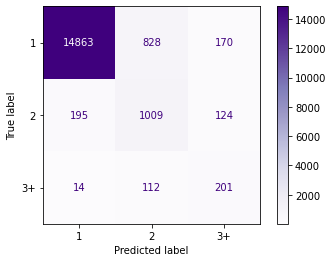

In [90]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)

mlp.fit(X_train_res, y_train_res)
y_pred_mlp = mlp.predict(X_test_cls)

print("Red Neuronal - MLP")
print(classification_report(y_test_cls, y_pred_mlp))

f1_macro = f1_score(y_test_cls, y_pred_mlp, average='macro')
print(f"F1-score promedio (macro): {f1_macro:.4f}")

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test_cls, y_pred_mlp, cmap="Purples")
